# 5. Convergence diagnostics: `snia.diagnostics`

Notebook 4 produced chains. Nothing there checked whether they had actually
converged, or how precisely the reported numbers are known. That is what this
notebook is for.

No single number proves convergence, so three complementary tools are used:

1. **autocorrelation** — how much independent information a chain carries
2. **split-$\hat{R}$** — do chains started far apart agree?
3. **the Dunkley power spectrum** — is the chain stationary, and long enough?

Like `snia.bayes`, this package imports neither `snia.cosmology` nor
`snia.data`: it takes plain `(n_chains, n_steps, n_params)` arrays, which is
what lets it be checked against a process with a known answer.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lfilter

from snia.diagnostics.autocorr import (
    autocorrelation, integrated_time, effective_sample_size, monte_carlo_error,
)
from snia.diagnostics.gelman_rubin import split_rhat, rank_normalized_rhat
from snia.diagnostics.spectral import power_spectrum, fit_dunkley

plt.rcParams["figure.figsize"] = (7, 4)


def ar1(phi, n_steps, rng, burn_in=2000):
    # x[t+1] = phi x[t] + noise: a chain whose correlation is known exactly
    noise = rng.normal(0.0, 1.0, n_steps + burn_in)
    return lfilter([1.0], [1.0, -phi], noise)[burn_in:]

## 1. The test process

Everything below is checked against an AR(1) process,

$$x_{t+1} = \phi\,x_t + \varepsilon,\qquad \varepsilon\sim\mathcal{N}(0,\sigma^2),$$

because every quantity we want to measure is known in closed form:

$$
\rho_\ell = \phi^{\ell},
\qquad
\tau_{\rm int} = \frac{1+\phi}{1-\phi},
\qquad
S(k) = \frac{\sigma^{2}}{1 - 2\phi\cos k + \phi^{2}} .
$$

Expanding $S$ for small $k$ gives the Dunkley form with
$P_0 = \sigma^2/(1-\phi)^2$, $k_\star = (1-\phi)/\sqrt{\phi}$ and $\alpha = 2$.

## 2. Autocorrelation and the integrated time

$$
\rho_\ell = \frac{{\rm Cov}(x_t, x_{t+\ell})}{{\rm Var}(x_t)},
\qquad
\tau_{\rm int} = 1 + 2\sum_{\ell\ge1}\rho_\ell .
$$

The sum has to be truncated: at large lag $\rho_\ell$ is estimated from ever
fewer pairs and is pure noise. `integrated_time` uses Sokal's rule — take the
smallest window $M$ with $M \ge 5\,\tau(M)$.

In [2]:
rng = np.random.default_rng(0)
chains = {phi: ar1(phi, 200000, rng) for phi in (0.0, 0.5, 0.8, 0.9)}

for phi, chain in chains.items():
    measured = integrated_time(chain)[0]
    analytic = (1 + phi) / (1 - phi)
    print(f"phi = {phi:4.2f}:  tau_int = {measured:7.3f}   analytic = {analytic:7.3f}")

phi = 0.00:  tau_int =   0.986   analytic =   1.000
phi = 0.50:  tau_int =   2.995   analytic =   3.000
phi = 0.80:  tau_int =   8.803   analytic =   9.000
phi = 0.90:  tau_int =  18.699   analytic =  19.000


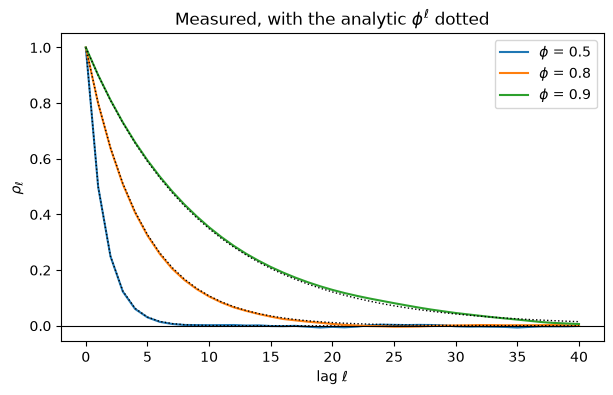

In [3]:
for phi in (0.5, 0.8, 0.9):
    rho = autocorrelation(chains[phi], max_lag=40)[:, 0]
    plt.plot(rho, label=f"$\\phi$ = {phi}")
    plt.plot(phi ** np.arange(41), "k:", lw=1)

plt.axhline(0, color="k", lw=0.8)
plt.xlabel(r"lag $\ell$")
plt.ylabel(r"$\rho_\ell$")
plt.title(r"Measured, with the analytic $\phi^\ell$ dotted")
plt.legend()
plt.show()

## 3. Effective sample size and Monte Carlo error

$$
N_{\rm eff} = \frac{N}{\tau_{\rm int}},
\qquad
{\rm MCSE}(\bar x) = \frac{s_x}{\sqrt{N_{\rm eff}}} .
$$

**Chain length is not sample size.** A correlated chain of $N$ draws carries
the information of roughly $N/\tau_{\rm int}$ independent ones, and it is that
number which sets the error on anything you report.

In [4]:
print(f"{'phi':>5} {'N':>8} {'tau_int':>9} {'ESS':>9} {'MCSE':>9} {'|mean|/MCSE':>12}")
for phi, chain in chains.items():
    ess = effective_sample_size(chain)[0]
    mcse = monte_carlo_error(chain)[0]
    print(f"{phi:5.2f} {chain.size:8d} {integrated_time(chain)[0]:9.2f} "
          f"{ess:9.0f} {mcse:9.5f} {abs(chain.mean()) / mcse:12.2f}")

print("\nThe true mean is 0, and every chain sits within a couple of MCSE of it.")
print("At phi = 0.9, 200000 draws are worth only about 10000 independent ones.")

  phi        N   tau_int       ESS      MCSE  |mean|/MCSE
 0.00   200000      0.99    202865   0.00222         0.13


 0.50   200000      2.99     66784   0.00447         0.28
 0.80   200000      8.80     22719   0.01103         1.85
 0.90   200000     18.70     10696   0.02225         0.48

The true mean is 0, and every chain sits within a couple of MCSE of it.
At phi = 0.9, 200000 draws are worth only about 10000 independent ones.


## 4. Split-$\hat{R}$: do dispersed chains agree?

$$
\hat{R} = \sqrt{\hat{V}/W},
\qquad
\hat V = \frac{n-1}{n}W + \frac{B}{n}
$$

with $W$ the mean within-chain variance and $B$ the between-chain variance.
$\hat R < 1.01$ is a useful guideline, not a guarantee.

Each chain is **split in half** first. That is what makes the statistic notice
a chain that is still drifting: if every chain drifts the same way there is no
between-chain spread at all, but the two halves of each chain end up in
different places.

In [5]:
rng = np.random.default_rng(1)
converged = np.stack([ar1(0.8, 8000, rng) for _ in range(4)])[:, :, np.newaxis]

offset = converged.copy()
offset[0] += 3.0                                     # one chain in the wrong place

wider = converged.copy()
wider[0] *= 3.0                                      # one chain too broad, same mean

drifting = converged + np.linspace(0, 4, 8000)[np.newaxis, :, np.newaxis]

print(f"{'case':34s} {'split-Rhat':>11} {'rank-normalized':>17}")
for name, sample in [("four healthy chains", converged),
                     ("one chain offset by 3 sigma", offset),
                     ("one chain 3x wider, same mean", wider),
                     ("all four drifting together", drifting)]:
    print(f"{name:34s} {split_rhat(sample)[0]:11.4f} {rank_normalized_rhat(sample)[0]:17.4f}")

case                                split-Rhat   rank-normalized
four healthy chains                     1.0006            1.0006
one chain offset by 3 sigma             1.3131            1.2842
one chain 3x wider, same mean           1.0004            1.1477
all four drifting together              1.1835            1.1819


Two of those rows are worth pausing on.

**"all four drifting together"** is caught only because the chains were split.
Without splitting, four identically drifting chains have no between-chain
spread and $\hat R$ would be about 1.

**"one chain 3× wider, same mean"** is missed by the plain statistic — it
compares *locations*, and the locations agree. The rank-normalized version
includes a *folded* variant computed on $|x - \mathrm{median}|$, which turns a
difference in scale into a difference in location. That is why both are
provided, and why the rank-normalized one is the one to report.

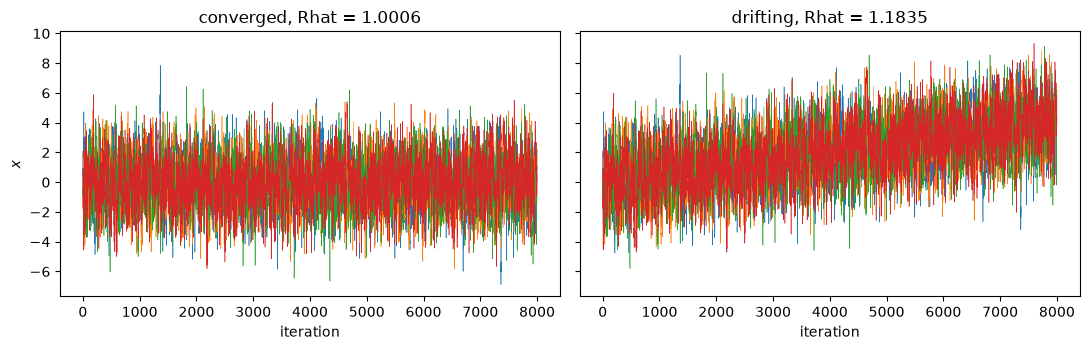

In [6]:
figure, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for chain in range(4):
    axes[0].plot(converged[chain, :, 0], lw=0.4)
    axes[1].plot(drifting[chain, :, 0], lw=0.4)
axes[0].set_title(f"converged, Rhat = {split_rhat(converged)[0]:.4f}")
axes[1].set_title(f"drifting, Rhat = {split_rhat(drifting)[0]:.4f}")
for axis in axes:
    axis.set_xlabel("iteration")
axes[0].set_ylabel("$x$")
plt.tight_layout()
plt.show()

## 5. The Dunkley power spectrum

A chain viewed in Fourier space,

$$
a_j = \frac{1}{\sqrt{N}}\sum_n (x_n - \bar x)\,e^{2\pi ijn/N},
\qquad
\hat P_j = |a_j|^{2},
\qquad
k_j = \frac{2\pi j}{N},
$$

separates two questions a trace plot mixes together. Dunkley et al. fit

$$
P(k) = \frac{P_0}{1 + (k/k_\star)^{\alpha}},
\qquad
j_\star = \frac{k_\star N}{2\pi},
\qquad
r = \frac{P_0}{N s_x^{2}},
$$

and require $j_\star > 20$ (enough long modes to resolve the white plateau) and
$r < 0.01$ (the mean is known to better than 10% of the posterior width).

The fit is by **maximum likelihood**, not least squares: the periodogram
ordinates scatter exponentially about the true spectrum, so the noise is
multiplicative, and $\log\hat P$ is biased low by a fixed amount.

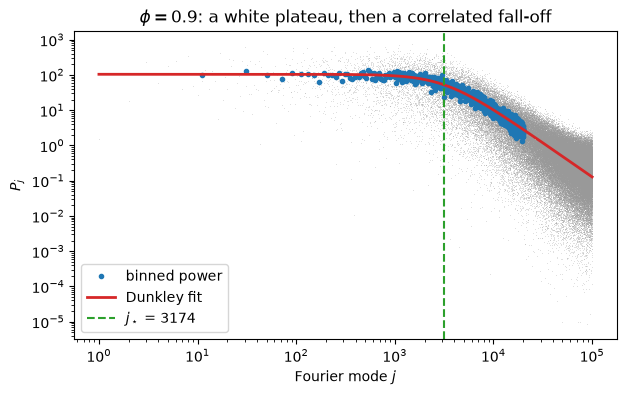

P0    =  104.570   analytic  100.000
k*    =  0.09971   analytic  0.10541
alpha =    1.943   analytic    2.000

DunkleySpectrum(P0=104.6, j_star=3173.9, alpha=1.94, r=9.88e-05) [PASS]


In [7]:
chain = chains[0.9]
j, power = power_spectrum(chain)
fit = fit_dunkley(chain)

k = 2 * np.pi * j / chain.size
model = fit.p0 / (1 + (k / fit.k_star) ** fit.alpha)

plt.loglog(j, power, ",", alpha=0.3, color="0.6")
binned = power[: 20000 // 20 * 20].reshape(-1, 20).mean(axis=1)
plt.loglog(j[10:20000:20], binned[:len(j[10:20000:20])], "o", ms=3, label="binned power")
plt.loglog(j, model, "C3", lw=2, label="Dunkley fit")
plt.axvline(fit.j_star, color="C2", ls="--", label=rf"$j_\star$ = {fit.j_star:.0f}")
plt.xlabel("Fourier mode $j$")
plt.ylabel("$P_j$")
plt.title(r"$\phi = 0.9$: a white plateau, then a correlated fall-off")
plt.legend()
plt.show()

print(f"P0    = {fit.p0:8.3f}   analytic {1 / (1 - 0.9)**2:8.3f}")
print(f"k*    = {fit.k_star:8.5f}   analytic {(1 - 0.9) / np.sqrt(0.9):8.5f}")
print(f"alpha = {fit.alpha:8.3f}   analytic {2.0:8.3f}")
print(f"\n{fit!r}")

### The two routes must agree

$P_0 = s_x^{2}\,\tau_{\rm int}$, so

$$
r = \frac{P_0}{N s_x^{2}} = \frac{\tau_{\rm int}}{N} = \frac{1}{N_{\rm eff}} .
$$

The spectral fit and the autocorrelation window share no code and no
assumptions beyond stationarity, so this is a real cross-check.

In [8]:
print(f"{'phi':>5} {'r (spectral)':>14} {'1/ESS (autocorr)':>18} {'ratio':>8}")
for phi in (0.5, 0.8, 0.9):
    chain = chains[phi]
    r = fit_dunkley(chain).r
    inverse_ess = 1.0 / effective_sample_size(chain)[0]
    print(f"{phi:5.2f} {r:14.3e} {inverse_ess:18.3e} {r / inverse_ess:8.3f}")

print("\nThe agreement improves as phi -> 1 because the Dunkley model is the")
print("SMALL-k expansion of the AR(1) spectrum: at phi = 0.5 the turnover sits")
print("at k* = 0.71, which is not small, and the fit compensates with a")
print("shallower alpha. Real MCMC chains live in the phi -> 1 regime.")

  phi   r (spectral)   1/ESS (autocorr)    ratio


 0.50      1.728e-05          1.497e-05    1.154


 0.80      4.619e-05          4.402e-05    1.049


 0.90      9.875e-05          9.349e-05    1.056

The agreement improves as phi -> 1 because the Dunkley model is the
SMALL-k expansion of the AR(1) spectrum: at phi = 0.5 the turnover sits
at k* = 0.71, which is not small, and the fit compensates with a
shallower alpha. Real MCMC chains live in the phi -> 1 regime.


### The thresholds have to bite

Running the same process at increasing length reproduces the progression in
the lecture: a short chain fails both tests, and both pass once it is long
enough.

In [9]:
rng = np.random.default_rng(2)
print(f"{'N':>8} {'j*':>10} {'r':>9}   {'white?':>7} {'mean ok?':>9} {'passes':>7}")
for n_steps in (500, 1200, 2500, 20000, 200000):
    fit = fit_dunkley(ar1(0.9, n_steps, rng))
    print(f"{n_steps:8d} {fit.j_star:10.1f} {fit.r:9.4f}   "
          f"{str(fit.white_regime_resolved):>7} {str(fit.mean_is_converged):>9} "
          f"{str(fit.passes):>7}")

       N         j*         r    white?  mean ok?  passes
     500        5.7    0.0561     False     False   False
    1200       14.8    0.0212     False     False   False
    2500       43.1    0.0073      True      True    True
   20000      315.8    0.0010      True      True    True


  200000     3237.8    0.0001      True      True    True


## 6. A convergence report for the real chains

Everything above applies unchanged to the Union2.1 posterior from notebook 4.
The chains are **unthinned** — thinning throws away information and would only
hide a diagnostic failure.

In [10]:
from snia.data.union21 import load_union21
from snia.data.likelihood import Union21Likelihood
from snia.bayes.posterior import Posterior, UniformPrior
from snia.bayes.proposals import GaussianRandomWalk
from snia.bayes.samplers import MetropolisHastings, run_chains

z, mu, cov = load_union21()
likelihood = Union21Likelihood(z, mu, cov)
posterior = Posterior(likelihood.log_likelihood, UniformPrior([0.0, -1.0], [2.0, 3.0]))

warmup = MetropolisHastings(
    posterior, GaussianRandomWalk(np.diag([0.05**2, 0.08**2]))
).sample([0.3, 0.7], 4000, np.random.default_rng(0))

production = run_chains(
    posterior,
    GaussianRandomWalk(np.cov(warmup.samples[1000:].T), scale=1.7),
    [[0.2, 0.5], [0.45, 0.95], [0.1, 0.85], [0.5, 0.6]],
    20000,
    np.random.default_rng(1),
)
retained = production.burned(2000)
print(f"{retained.n_chains} chains x {retained.n_steps} steps, "
      f"acceptance {np.round(production.acceptance_rate, 3)}")

4 chains x 18000 steps, acceptance [0.338 0.328 0.335 0.34 ]


In [11]:
names = ["Omega_m", "Omega_Lambda"]
samples = retained.samples
flat = retained.flat()

print(f"{'parameter':14s} {'mean':>9} {'sd':>8} {'tau_int':>9} {'ESS':>8} "
      f"{'MCSE':>9} {'Rhat':>8}")
for index, name in enumerate(names):
    print(f"{name:14s} {flat[:, index].mean():9.4f} {flat[:, index].std():8.4f} "
          f"{integrated_time(samples)[index]:9.2f} "
          f"{effective_sample_size(samples)[index]:8.0f} "
          f"{monte_carlo_error(samples)[index]:9.5f} "
          f"{rank_normalized_rhat(samples)[index]:8.4f}")

print("\nDunkley test, applied per chain and per parameter (unthinned):")
for index, name in enumerate(names):
    verdicts = [fit_dunkley(samples[c, :, index]) for c in range(retained.n_chains)]
    print(f"  {name}")
    for chain, fit in enumerate(verdicts):
        print(f"    chain {chain}: j* = {fit.j_star:7.1f}  r = {fit.r:.5f}  "
              f"{'PASS' if fit.passes else 'FAIL'}")

parameter           mean       sd   tau_int      ESS      MCSE     Rhat
Omega_m           0.2798   0.1120      7.58     9495   0.00115   1.0003
Omega_Lambda      0.6590   0.2095      7.63     9432   0.00216   1.0006

Dunkley test, applied per chain and per parameter (unthinned):


  Omega_m
    chain 0: j* =   740.2  r = 0.00042  PASS
    chain 1: j* =   680.9  r = 0.00046  PASS
    chain 2: j* =   638.2  r = 0.00047  PASS
    chain 3: j* =   728.5  r = 0.00044  PASS
  Omega_Lambda
    chain 0: j* =   711.1  r = 0.00044  PASS
    chain 1: j* =   667.4  r = 0.00047  PASS
    chain 2: j* =   662.1  r = 0.00047  PASS
    chain 3: j* =   705.6  r = 0.00045  PASS


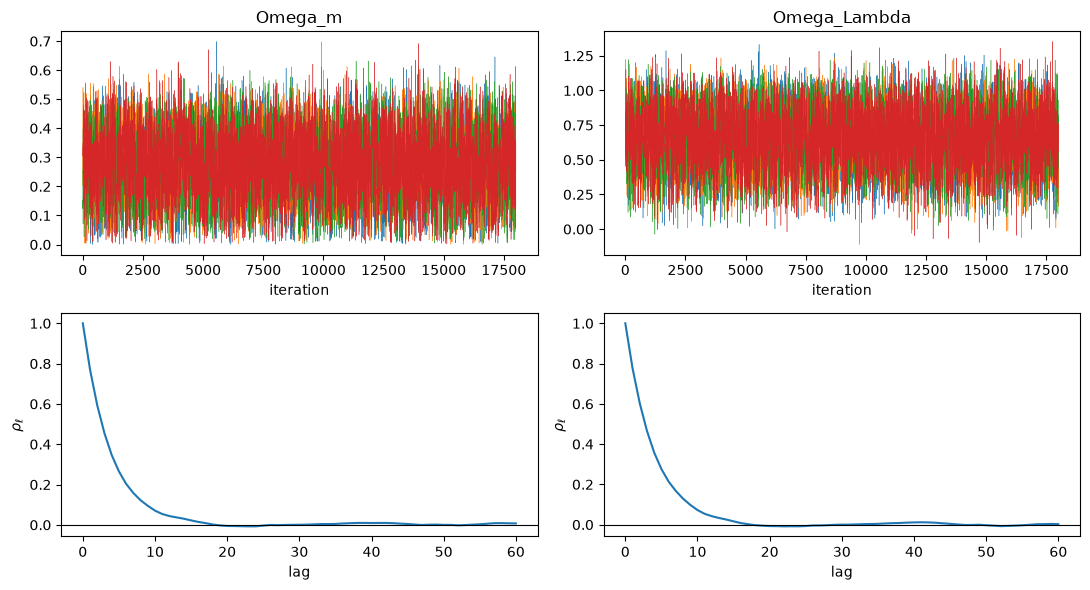

In [12]:
figure, axes = plt.subplots(2, 2, figsize=(11, 6))
for index, name in enumerate(names):
    for chain in range(retained.n_chains):
        axes[0, index].plot(samples[chain, :, index], lw=0.3)
    axes[0, index].set_title(name)
    axes[0, index].set_xlabel("iteration")

    axes[1, index].plot(autocorrelation(samples, max_lag=60)[:, index])
    axes[1, index].axhline(0, color="k", lw=0.8)
    axes[1, index].set_xlabel("lag")
    axes[1, index].set_ylabel(r"$\rho_\ell$")
plt.tight_layout()
plt.show()

## 7. What the diagnostics do not tell you

Every test here can be passed by a chain that has explored only one mode of a
multimodal posterior: it will look stationary, its spectrum will be white, and
several chains started nearby will agree with each other beautifully.

That is why the chains are started **dispersed**, and why the thresholds are
guidelines rather than proofs. A spectral pass tests stationarity and the
precision of the mean, not global exploration.

## Summary

| function | what it gives |
| --- | --- |
| `autocorrelation(samples, max_lag)` | $\rho_\ell$, averaged over chains |
| `integrated_time(samples)` | $\tau_{\rm int}$ with Sokal's window |
| `effective_sample_size(samples)` | $N/\tau_{\rm int}$ |
| `monte_carlo_error(samples)` | $s/\sqrt{N_{\rm eff}}$ |
| `split_rhat(samples)` | classic split-$\hat{R}$ |
| `rank_normalized_rhat(samples)` | robust to heavy tails, sensitive to scale |
| `power_spectrum(chain)` | the Fourier modes $j$ and $\hat P_j$ |
| `fit_dunkley(chain)` | $P_0$, $k_\star$, $\alpha$, $j_\star$, $r$ and the pass flags |

All of them take plain `(n_chains, n_steps, n_params)` arrays; a 1-D array is
one chain of one parameter, and a 2-D array is what
`MetropolisHastings.sample` returns.
